## Imports

In [1]:
# Kaggle notebook setup
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## Download data to colab

In [2]:
# Explore the dataset structure
data_path = "./CrisisMMD_v2.0/"

# Download dataset
! gdown 1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI

# Unzip
! tar -xzf "CrisisMMD_v2.0.tar.gz"

# List all disaster events
annotation_files = os.listdir(f"{data_path}annotations/")
print("Disaster events:", annotation_files)

# Load first annotation file to understand structure
sample_annotations = pd.read_csv(f"{data_path}annotations/{annotation_files[0]}", sep='\t')
print("Dataset shape:", sample_annotations.shape)
print("Columns:", sample_annotations.columns.tolist())
sample_annotations.head()

Downloading...
From (original): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI
From (redirected): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI&confirm=t&uuid=d56328fa-7ea5-4daf-9e00-95392b5822b8
To: /content/CrisisMMD_v2.0.tar.gz
100% 1.90G/1.90G [00:26<00:00, 72.0MB/s]
Disaster events: ['california_wildfires_final_data.tsv', '._california_wildfires_final_data.tsv', 'mexico_earthquake_final_data.tsv', 'srilanka_floods_final_data.tsv', 'hurricane_maria_final_data.tsv', '._hurricane_irma_final_data.tsv', '._hurricane_maria_final_data.tsv', '._srilanka_floods_final_data.tsv', 'iraq_iran_earthquake_final_data.tsv', 'hurricane_irma_final_data.tsv', 'hurricane_harvey_final_data.tsv']
Dataset shape: (1589, 15)
Columns: ['tweet_id', 'image_id', 'text_info', 'text_info_conf', 'image_info', 'image_info_conf', 'text_human', 'text_human_conf', 'image_human', 'image_human_conf', 'image_damage', 'image_damage_conf', 'tweet_text', 'image_url', 'image_path']


,tweet_id,image_id,text_info,text_info_conf,image_info,image_info_conf,text_human,text_human_conf,image_human,image_human_conf,image_damage,image_damage_conf,tweet_text,image_url,image_path
0,917791044158185473,917791044158185473_0,informative,1.0000,informative,0.6766,other_relevant_information,1.0000,other_relevant_information,0.6766,NaN,NaN,RT @Gizmodo: Wildfires raging through Northern...,http://pbs.twimg.com/media/DLyi_WYVYAApwNg.jpg,data_image/california_wildfires/10_10_2017/917...
1,917791130590183424,917791130590183424_0,informative,1.0000,informative,0.6667,infrastructure_and_utility_damage,1.0000,affected_individuals,0.6667,NaN,NaN,PHOTOS: Deadly wildfires rage in California ht...,http://pbs.twimg.com/media/DLymKm9UMAAu0qw.jpg,data_image/california_wildfires/10_10_2017/917...
2,917791291823591425,917791291823591425_0,informative,0.6813,informative,1.0000,other_relevant_information,0.6813,infrastructure_and_utility_damage,1.0000,severe_damage,1.0,RT @Cal_OES: PLS SHARE: Weâ€™re capturing wild...,http://pbs.twimg.com/media/DLudaaZV4AAjT7x.jpg,data_image/california_wildfires/10_10_2017/917...
3,917791291823591425,917791291823591425_1,informative,0.6813,not_informative,1.0000,other_relevant_information,0.6813,not_humanitarian,1.0000,NaN,NaN,RT @Cal_OES: PLS SHARE: Weâ€™re capturing wild...,http://pbs.twimg.com/media/DLudaZXUMAABAEZ.jpg,data_image/california_wildfires/10_10_2017/917...
4,917792092100988929,917792092100988929_0,informative,0.6727,informative,0.6612,other_relevant_information,0.6727,infrastructure_and_utility_damage,0.6612,severe_damage,1.0,RT @TIME: California's raging wildfires as you...,http://pbs.twimg.com/media/DLwNe-NXUAE0XCw.jpg,data_image/california_wildfires/10_10_2017/917...


## Data to df

In [3]:
# Analyze all disaster events and create unified dataset
def load_all_annotations():
    all_data = []
    disaster_events = []
    
    for file in annotation_files:
        if file.endswith('.tsv'):
            event_name = file.replace('.tsv', '')
            df = pd.read_csv(f"{data_path}annotations/{file}", sep='\t', encoding='latin1')
            df['disaster_event'] = event_name
            all_data.append(df)
            disaster_events.append(event_name)
            
    combined_df = pd.concat(all_data, ignore_index=True)
    return combined_df, disaster_events

combined_data, events = load_all_annotations()
print(f"Total samples: {len(combined_data)}")
print(f"Events: {events}")

Total samples: 18082
Events: ['california_wildfires_final_data', '._california_wildfires_final_data', 'mexico_earthquake_final_data', 'srilanka_floods_final_data', 'hurricane_maria_final_data', '._hurricane_irma_final_data', '._hurricane_maria_final_data', '._srilanka_floods_final_data', 'iraq_iran_earthquake_final_data', 'hurricane_irma_final_data', 'hurricane_harvey_final_data']


In [4]:
dataset = combined_data[["tweet_id","image_id","text_info","image_info", "tweet_text","image_path"]]
dataset.head()


,tweet_id,image_id,text_info,image_info,tweet_text,image_path
0,9.177910e+17,917791044158185473_0,informative,informative,RT @Gizmodo: Wildfires raging through Northern...,data_image/california_wildfires/10_10_2017/917...
1,9.177911e+17,917791130590183424_0,informative,informative,PHOTOS: Deadly wildfires rage in California ht...,data_image/california_wildfires/10_10_2017/917...
2,9.177913e+17,917791291823591425_0,informative,informative,RT @Cal_OES: PLS SHARE: WeÃ¢â¬â¢re capturing...,data_image/california_wildfires/10_10_2017/917...
3,9.177913e+17,917791291823591425_1,informative,not_informative,RT @Cal_OES: PLS SHARE: WeÃ¢â¬â¢re capturing...,data_image/california_wildfires/10_10_2017/917...
4,9.177921e+17,917792092100988929_0,informative,informative,RT @TIME: California's raging wildfires as you...,data_image/california_wildfires/10_10_2017/917...


## Dataset Class for CrisisMMD images

In [5]:
class CrisisVisionDataset(Dataset):
    def __init__(self, dataframe, base_image_dir, transform=None):
        """
        Args:
            dataframe: Your pandas DataFrame.
            base_image_dir: The root folder where all CrisisMMD images are stored.
            transform: PyTorch transforms (ResNet preprocessing).
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.base_image_dir = base_image_dir
        self.transform = transform
        
        # We strictly use 'image_info' for the vision model (Modality Dissonance rule!)
        # Map 'informative' to 1 (Disaster) and 'not_informative' to 0 (Safe)
        self.dataframe['label'] = self.dataframe['image_info'].apply(
            lambda x: 1 if x == 'informative' else 0
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Get the image path from the dataframe
        # CrisisMMD usually has relative paths like 'california_wildfires/1234.jpg'
        rel_path = self.dataframe.loc[idx, 'image_path']
        img_path = os.path.join(self.base_image_dir, rel_path)
        
        # 2. Open the image and ensure it is RGB (fixes issues with grayscale/PNGs)
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # If an image is corrupted or missing, print a warning and return a dummy 
            # or handle it (for simplicity, we assume data is clean here)
            print(f"Warning: Could not open {img_path}")
            image = Image.new('RGB', (224, 224)) 

        # 3. Apply ResNet preprocessing
        if self.transform:
            image = self.transform(image)
            
        # 4. Get the label
        label = self.dataframe.loc[idx, 'label']
        
        # 5. Return the math tensor and the label
        # We convert label to a PyTorch tensor of type long (standard for classification)
        return image, torch.tensor(label, dtype=torch.long)

## Transforms

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p=0.5),      # Randomly flip images left/right
    transforms.RandomRotation(15),               # Slightly tilt the images
    transforms.ColorJitter(brightness=0.2),      # Simulate different lighting
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# TESTING Pipeline (Strict, clean, no chaos)
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Dataloaders

In [7]:
# Assuming 'df' is your current DataFrame
# First, let's split it into 80% Training and 20% Testing
train_df, test_df = train_test_split(dataset, test_size=0.2, random_state=42)

# Define the root directory where your images are stored on your machine/Colab
BASE_IMG_DIR = "./CrisisMMD_v2.0/" 

# Create the Dataset objects
train_dataset = CrisisVisionDataset(
    dataframe=train_df, 
    base_image_dir=BASE_IMG_DIR, 
    transform=train_transforms
)

test_dataset = CrisisVisionDataset(
    dataframe=test_df, 
    base_image_dir=BASE_IMG_DIR, 
    transform=test_transforms
)

# Create the DataLoaders
# batch_size=32 is standard. num_workers speeds up data loading by using CPU cores.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")

# --- Quick Test to verify it works ---
# Grab one batch of images and labels
images, labels = next(iter(train_loader))
print(f"\nBatch Image Tensor Shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Batch Labels Shape: {labels.shape}")         # Should be [32]

Training batches: 453
Testing batches: 114

Batch Image Tensor Shape: torch.Size([32, 3, 224, 224])
Batch Labels Shape: torch.Size([32])


## Training

In [8]:
print("Loading pre-trained ResNet50...")
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# 1. Freeze EVERYTHING first
for param in model.parameters():
    param.requires_grad = False

# 2. UNFREEZE the final convolutional block (layer4)
for param in model.layer4.parameters():
    param.requires_grad = True

# 3. Replace the final layer
model.fc = nn.Linear(model.fc.in_features, 2)

# 4. CRITICAL: Give the optimizer BOTH the unfreezed block and the final layer!
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4}, # Train the body slowly
    {'params': model.fc.parameters(), 'lr': 1e-3}      # Train the head normally
]) # weight_decay=1e-4) # L2 regularization to prevent overfitting MADE IT WORSE, REMOVED

# Move the model to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

# CrossEntropyLoss is the standard for classification
criterion = nn.CrossEntropyLoss()

EPOCHS = 3

print("Starting training...")
for epoch in range(EPOCHS):
    model.train() # Tell PyTorch we are in training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    # tqdm gives us a nice progress bar in Colab
    loop = tqdm(train_loader, leave=True)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # --- Keep track of stats for printing ---
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

print("Training Complete!")

# We save the "state_dict" (the mathematical weights) to a file.
# You will load this exact file later for the Fusion Step!
torch.save(model.state_dict(), "vision_brain.pth")
print("Saved model weights to 'vision_brain.pth'")

Loading pre-trained ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 124MB/s] 


Using device: cuda
Starting training...


Epoch [3/3]: 100%|██████████| 453/453 [02:39<00:00,  2.84it/s, acc=89.2, loss=0.604] 


Training Complete!
Saved model weights to 'vision_brain.pth'


Training batches: 453
Testing batches: 114

Batch Image Tensor Shape: torch.Size([32, 3, 224, 224])
Batch Labels Shape: torch.Size([32])
Loading pre-trained ResNet50...
Using device: cuda
Starting training...
Epoch [1/10]: 100%|██████████| 453/453 [02:46<00:00,  2.73it/s, acc=79.6, loss=0.731]
Epoch [2/10]: 100%|██████████| 453/453 [02:43<00:00,  2.77it/s, acc=85.1, loss=0.493]
Epoch [3/10]: 100%|██████████| 453/453 [02:43<00:00,  2.76it/s, acc=88.7, loss=0.606] 
Epoch [4/10]: 100%|██████████| 453/453 [02:43<00:00,  2.77it/s, acc=91.7, loss=0.482] 
Epoch [5/10]: 100%|██████████| 453/453 [02:44<00:00,  2.76it/s, acc=93.2, loss=1.92]  
Epoch [6/10]: 100%|██████████| 453/453 [02:45<00:00,  2.73it/s, acc=95.1, loss=0.959] 
Epoch [7/10]: 100%|██████████| 453/453 [02:44<00:00,  2.75it/s, acc=95.7, loss=0.185] 
Epoch [8/10]: 100%|██████████| 453/453 [02:45<00:00,  2.74it/s, acc=95.9, loss=0.565]  
Epoch [9/10]: 100%|██████████| 453/453 [02:43<00:00,  2.77it/s, acc=96.4, loss=0.98]   
Epoch [10/10]: 100%|██████████| 453/453 [02:44<00:00,  2.75it/s, acc=96.7, loss=0.166]  
Training Complete!
Saved model weights to 'teammate2_vision_brain.pth'

## Save model with weights

Option 1. Save model weights to drive (code below)\
~~Option 2. Save model weights to github by manually moving `vision_brain.pth` under `Data-Science-Project/weights`~~

In [14]:
from google.colab import drive
import shutil

# This will prompt you to click a link and log in to your Google account
drive.mount('/content/drive')

# Copy the model from Colab's temporary storage to your permanent Drive
source_file = "vision_brain.pth"

# Change "My Drive" to a specific folder path if you want!
destination_file = "/content/drive/My Drive/vision_brain.pth" 

shutil.copy(source_file, destination_file)
print("Model safely backed up to Google Drive!")

Mounted at /content/drive
Model safely backed up to Google Drive!


## Test model

Starting evaluation on the Test Set...
Evaluation complete!

--- VISION MODEL (RESNET) RESULTS ---
Test Accuracy: 82.31%
Test F1 Score: 0.8242


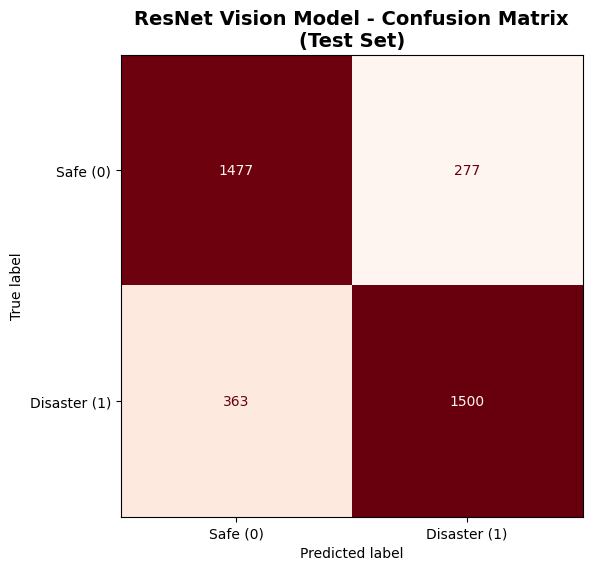

In [13]:
model.eval()

# Lists to store the model's guesses and the real answers
all_predictions = []
all_true_labels = []

print("Starting evaluation on the Test Set...")

# torch.no_grad() tells PyTorch to stop tracking math for gradients.
# This makes testing run incredibly fast and saves a massive amount of RAM.
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the GPU
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        # Get the highest probability class (0 for Safe, 1 for Disaster)
        _, predicted_classes = torch.max(outputs, dim=1)
        
        # Move the results back to the CPU memory and save them to our lists
        all_predictions.extend(predicted_classes.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

print("Evaluation complete!")

# Calculate standard metrics
accuracy = accuracy_score(all_true_labels, all_predictions)
f1 = f1_score(all_true_labels, all_predictions, average='binary')

print(f"\n--- VISION MODEL (RESNET) RESULTS ---")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test F1 Score: {f1:.4f}")

# Generate the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe (0)", "Disaster (1)"])

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Reds', ax=ax, colorbar=False) # Using Reds to contrast with the NLP model's Blues!
plt.title('ResNet Vision Model - Confusion Matrix\n(Test Set)', fontsize=14, fontweight='bold')
plt.grid(False) 
plt.show()

--- VISION MODEL (RESNET) RESULTS ---
Test Accuracy: 81.64%
Test F1 Score: 0.8241